In [1]:
from src.agents import ABPruningAgent, MiniMaxAgent
import gymnasium as gym

/Users/mario/Documents/proj/cam/Blokus/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment gymnasium_env/Blokus-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
BOARD_SIZE = 7
abpruning_agent = ABPruningAgent(board_size=BOARD_SIZE, depth=5)
# get_action2 = MiniMaxAgent(board_size=BOARD_SIZE).get_action

Neighborhood to encoded actions loaded
Initialised on good mode
Cache not found for MiniMaxAgent with depth 5 and board size 7


In [3]:
env = gym.make('gymnasium_env/Blokus-v0', board_size=BOARD_SIZE, num_players=2, render_scale=10, mode = "good")
env = env.unwrapped

Initialised on good mode


In [4]:
obs, info = env.reset()
# env.render_mode = "human"
# env.step(28)
# action1 = env._tuple_to_action((4, 4, 'F', 7))
# env.step(action1)
# action2 = env._tuple_to_action((0, 3, 'Y', 4))
# env.step(action2)
# action3 = env._tuple_to_action((4, 1, 'T5', 1))
# env.step(action3)
# action4 = env._tuple_to_action((2, 3, 'L5', 1))
# env.step(action4)
# action5 = env._tuple_to_action((2, 0, 'Y', 1))
# env.step(action5)
# action6 = 1752
# env.step(action6)
# action7 = 1456
# env.step(action7)
# action8 = 4187
# env.step(action8)
# action9 = 911
# obs1, rewrd, term, trunc, info1 = env.step(action9)
# env.render()
action = abpruning_agent.get_action(env, obs)
print(abpruning_agent.num_pruned)
print(action)
# action = get_action2(env, obs)

BValue: -inf, BAction: (-1, 6, 'Z5', 3), CAction: (np.int64(0), np.int64(0), 'F', 0),:   0%|          | 0/58 [00:00<?, ?it/s]

BValue: 5, BAction: (np.int64(0), np.int64(0), 'F', 0), CAction: (np.int64(0), np.int64(0), 'N', 3),:   9%|▊         | 5/58 [00:41<07:22,  8.35s/it]


KeyboardInterrupt: 

In [5]:
print(env._action_to_tuple(action))

abpruning_agent.save_cache()

(np.int64(0), np.int64(0), 'L5', 1)


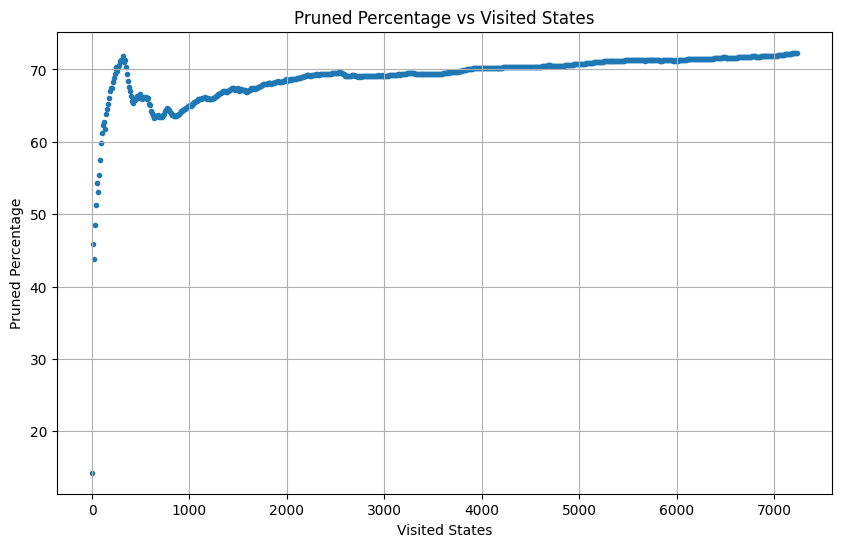

In [6]:
import matplotlib.pyplot as plt

# Assuming self.log is a list of tuples (num_pruned, visited_states, pruned_percentage)
log_data = abpruning_agent.log

# Extract visited_states and pruned_percentage
num_pruned = [entry[0] for entry in log_data]
visited_states = [entry[1] for entry in log_data]
pruned_percentage = [entry[2] for entry in log_data]

# Plot the data
plt.figure(figsize=(10, 6))
K = 10
plt.scatter(num_pruned[::K], pruned_percentage[::K], marker='.')
plt.xlabel('Visited States')
plt.ylabel('Pruned Percentage')
plt.title('Pruned Percentage vs Visited States')
plt.grid(True)
plt.show()